# Wolof character-encoder pretraining

This notebook pretrains the encoder used by TNT V3 on the unpaired formal-news and informal-YouTube corpus. It uses masked-character span prediction, not normalization pairs. Gold development and test are not used by this objective.

The default model has about 1.44M parameters and the measured five-epoch runtime on the local RTX 5060 Laptop GPU is approximately 2–4 minutes, including validation and checkpoint overhead.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling.wolof_encoder_pretraining import (
    EncoderPretrainingConfig,
    MaskedCharacterCollator,
    benchmark_pretraining_speed,
    evaluate_pretraining_test,
    load_transferable_encoder_state,
    prepare_pretraining,
    train_encoder,
)

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('GPU memory (GiB):', round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2))

c:\Users\thioy\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTorch: 2.8.0+cu129
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
GPU memory (GiB): 7.96


## 1. Fixed pretraining configuration

The encoder dimensions exactly match TNT V3. The sampler targets 25% formal-news and 75% informal-comment rows. This compensates for the corpus imbalance without duplicating files or consulting normalization metrics.

In [2]:
CONFIG = EncoderPretrainingConfig(
    seed=2026,
    train_epochs=5,
    train_batch_size=256,
    evaluation_batch_size=512,
    learning_rate=3e-4,
    mask_probability=0.15,
    min_mask_span=1,
    max_mask_span=3,
    formal_sampling_fraction=0.25,
    mixed_precision='bf16',
    num_workers=0,  # Reliable in Windows/Jupyter
)
prepared = prepare_pretraining(CONFIG)

print('Fingerprint:', prepared['fingerprint'])
print('Rows:', {name: len(data) for name, data in prepared['datasets'].items()})
print('Vocabulary size:', len(prepared['vocabulary']))
print('Parameters:', json.dumps(prepared['parameter_report'], indent=2))
print('Checkpoint directory:', prepared['run_dir'])
print('Results directory:', prepared['results_dir'])

Fingerprint: 476eeb46caee1a5eac4edc3d568ec1bb60ec53f18f4355bcd7a7d8844ec9530a
Rows: {'train': 54363, 'dev': 3018, 'test': 3018}
Vocabulary size: 272
Parameters: {
  "character_embedding": 52224,
  "position_embedding": 49152,
  "encoder": 1334592,
  "transferable_parameters": 1435968,
  "pretraining_parameters": 1436240,
  "fp32_weight_megabytes": 5.47882080078125
}
Checkpoint directory: C:\Users\thioy\Desktop\School\PFE\checkpoints\wolof_encoder_pretraining_v1\476eeb46caee
Results directory: C:\Users\thioy\Desktop\School\PFE\results\wolof_encoder_pretraining_v1\476eeb46caee


## 2. Inspect the corruption objective

Only selected characters contribute to the loss. `[MASK]` replaces 80% of selected positions, a random character replaces 10%, and the original character remains for 10%. EOS and padding are never prediction targets.

In [3]:
vocabulary = prepared['vocabulary']
inverse_vocabulary = {value: key for key, value in vocabulary.items()}
collator = MaskedCharacterCollator(
    vocabulary, mask_probability=CONFIG.mask_probability,
    min_span=CONFIG.min_mask_span, max_span=CONFIG.max_mask_span, seed=CONFIG.seed,
)
rows = [prepared['datasets']['train'][index] for index in range(3)]
batch = collator(rows)
for index, row in enumerate(rows):
    length = len(row['input_ids'])
    original = ''.join(inverse_vocabulary[token] for token in row['input_ids'][:-1])
    corrupted = ''.join(inverse_vocabulary[int(token)] for token in batch['input_ids'][index, :length-1])
    targets = ''.join(
        inverse_vocabulary[int(label)] if int(label) != -100 else '·'
        for label in batch['labels'][index, :length-1]
    )
    print(f'\n{row["domain"]} | {row["source_id"]}')
    print('Original :', original)
    print('Corrupted:', corrupted)
    print('Targets  :', targets)


formal_news | news:1583:0
Original : 2002, ATUM SUUXU JOOLAA BI
Corrupted: 2<mask>02, ATU<mask> SUUXU JOOLA<mask> BI
Targets  : ·0·······M ···········A···

formal_news | news:1584:0
Original : Bërki-démb 26 sàttumbar ci atum 2020, “Bateau le Joolaa” def na 18i at ci biir géej. Daanaka ñaari-junni nit ñàkkoon nañ ci seen bakkan. Te mujjagul fenn, ay daan amaguñ ci. Moonte kenn mësula gis jéeya ju tollu nii, mu waroon a tax askan
Corrupted: Bër<mask>§-démb 26 sàttumbar ci atum 2020, “Bateau <mask><mask> Jool<mask>a<mask> def na 18<mask> at ci biir g<mask>ej. D<mask>an<mask><mask>a ñaari-jun<mask><mask><mask>n<mask><mask><mask>ñàkkoon nañ c<mask><mask>s<mask>en bakkan. Te m<mask>jjagul fe<mask><mask>, <mask>y<mask><mask><mask>an amaguñ ci. Moont<mask> kenn mësula gis<mask><mask>éeya ju tollu nii, m<mask> waroon a t<mask>x askan
Targets  : ···ki·········································le·····aa”··········i··· ·········é·····a··ak···········ni ·it ·············i ·e···············u·········

## 3. Optional local speed test

This runs 20 throwaway forward/backward steps. It does not create a checkpoint and is not part of the real training run.

In [4]:
RUN_SPEED_TEST = False
if RUN_SPEED_TEST:
    speed = benchmark_pretraining_speed(prepared, batches=20)
    print(json.dumps(speed, indent=2))

## 4. Train or resume

Run this cell to start training. Progress is shown for every batch. The latest checkpoint is saved after every epoch; rerunning the cell resumes at the next unfinished epoch. The best encoder is selected using masked-character loss on the pretraining development split.

In [5]:
RUN_PRETRAINING = True
if RUN_PRETRAINING:
    training_result = train_encoder(prepared, resume=True)
    display(training_result['history'])
    print('Best encoder:', training_result['best_checkpoint'])

Device=cuda | parameters=1,436,240 | train rows=54,363 | steps/epoch=213


Epoch 1/5:   0%|          | 0/213 [00:00<?, ?it/s]

Dev epoch 1:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1: train loss=3.1352, dev loss=2.6820, dev accuracy=0.269 [best]


Epoch 2/5:   0%|          | 0/213 [00:00<?, ?it/s]

...

Epoch 5/5:   0%|          | 0/213 [00:00<?, ?it/s]

Dev epoch 5:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 5: train loss=2.7562, dev loss=2.6415, dev accuracy=0.271 [best]


,epoch,train_loss,train_masked_accuracy,dev_loss,dev_masked_accuracy,learning_rate
0,1,3.135153,0.247339,2.682002,0.269358,0.000253
1,2,2.782997,0.266589,2.658422,0.268974,0.000189
2,3,2.770862,0.267901,2.651970,0.269847,0.000126
3,4,2.763218,0.269355,2.644384,0.269987,0.000063
4,5,2.756181,0.269811,2.641521,0.271279,0.000000


Best encoder: C:\Users\thioy\Desktop\School\PFE\checkpoints\wolof_encoder_pretraining_v1\476eeb46caee\best_encoder.pt


## 5. Inspect saved results

This cell is safe to rerun. It reads the history and displays the curve written during training.

,epoch,train_loss,train_masked_accuracy,dev_loss,dev_masked_accuracy,learning_rate
0,1,3.135153,0.247339,2.682002,0.269358,0.000253
1,2,2.782997,0.266589,2.658422,0.268974,0.000189
2,3,2.770862,0.267901,2.651970,0.269847,0.000126
3,4,2.763218,0.269355,2.644384,0.269987,0.000063
4,5,2.756181,0.269811,2.641521,0.271279,0.000000


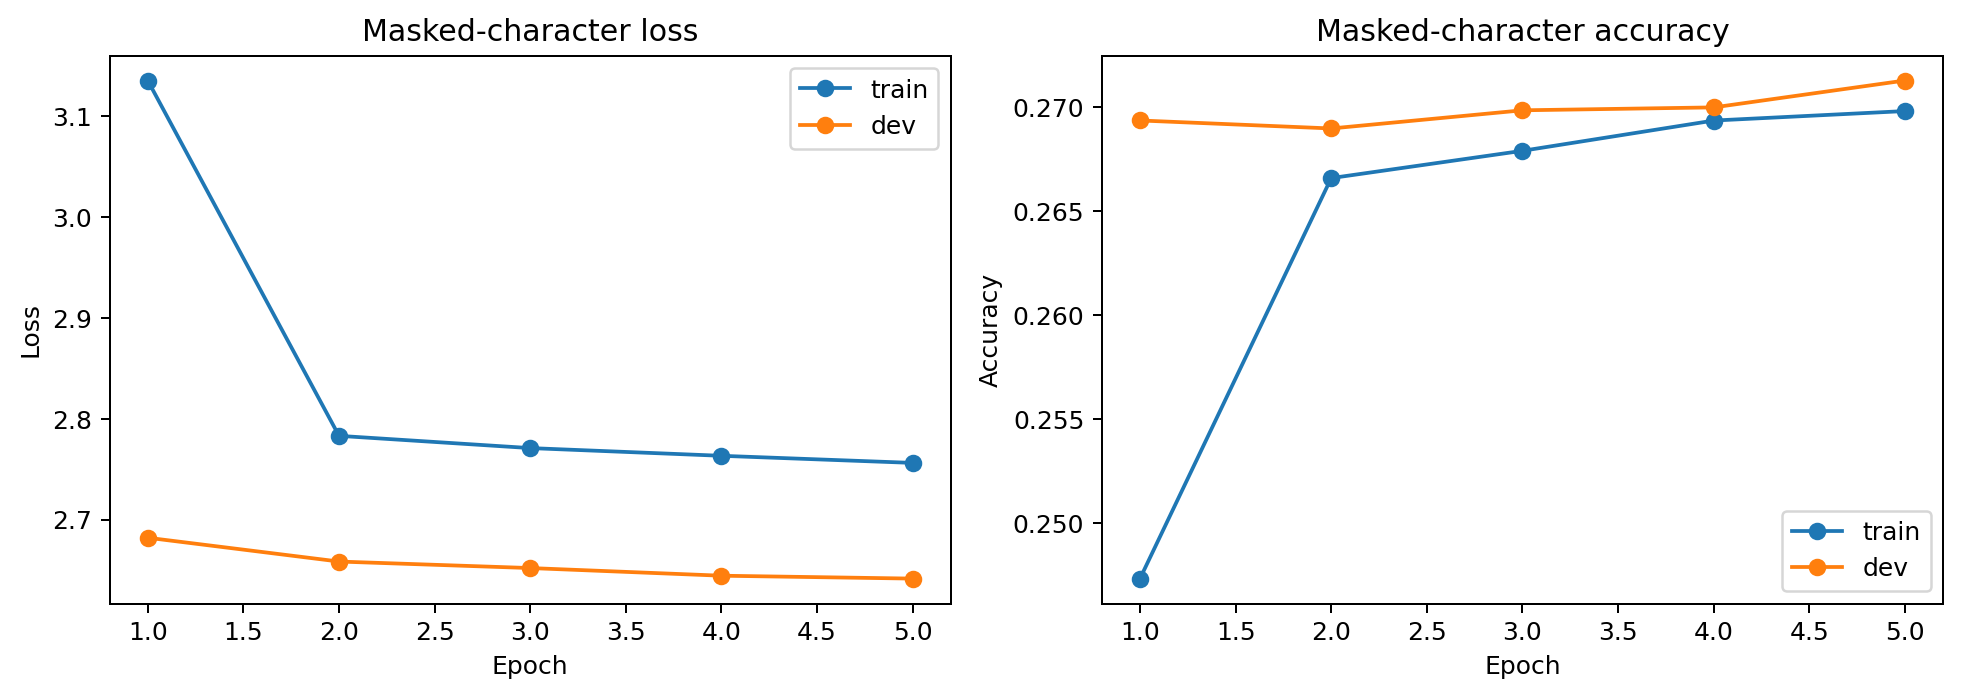

In [6]:
from IPython.display import Image, display

history_path = Path(prepared['results_dir']) / 'training_history.csv'
curve_path = Path(prepared['results_dir']) / 'training_curves.png'
if history_path.is_file():
    display(pd.read_csv(history_path))
if curve_path.is_file():
    display(Image(filename=str(curve_path)))

## 6. One-time pretraining-test evaluation

Keep this disabled until the development-selected run is complete and accepted. This is the unpaired masked-character test—not the frozen Gold normalization test.

In [9]:
RUN_PRETRAINING_TEST = True
if RUN_PRETRAINING_TEST:
    test_metrics = evaluate_pretraining_test(prepared)
    print(json.dumps(test_metrics, indent=2))

Pretraining test:   0%|          | 0/6 [00:00<?, ?it/s]

{
  "created_utc": "2026-09-29T14:54:25.022240+00:00",
  "selected_epoch": 5,
  "checkpoint": "C:\\Users\\thioy\\Desktop\\School\\PFE\\checkpoints\\wolof_encoder_pretraining_v1\\476eeb46caee\\best_encoder.pt",
  "loss": 2.6500535460557635,
  "masked_accuracy": 0.2698189712972127,
  "masked_characters": 31321,
  "rows": 3018
}


## 7. Transfer readiness check

After training, this verifies that the checkpoint contains the character embeddings, positional embeddings, and Transformer encoder tensors needed by TNT V3. Actual M1 transfer and normalization training will be kept in a separate controlled notebook.

In [8]:
best_checkpoint = Path(prepared['run_dir']) / 'best_encoder.pt'
if best_checkpoint.is_file():
    transferable = load_transferable_encoder_state(best_checkpoint)
    print('Transferable tensors:', len(transferable))
    print('Transferable parameters:', sum(tensor.numel() for tensor in transferable.values()))
    print('Prefixes:', sorted({name.split('.')[0] for name in transferable}))

Transferable tensors: 38
Transferable parameters: 1435968
Prefixes: ['character_embedding', 'encoder', 'position_embedding']
